In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import linalg
from scipy.spatial.distance import cdist
import os
from PIL import Image
import math

A.2: Recover Homographies

In [378]:
#part2 ComputeH function 
def computeH1(im1_pts,im2_pts): 
    im1_pts = np.array(im1_pts)
    im2_pts = np.array(im2_pts)
    n = im1_pts.shape[0]
    
    if n < 4:
        raise ValueError("At least 4 point correspondences are required")
    
    A = []
    for i in range(n): 
        x,y = im1_pts[i]
        xp, yp = im2_pts[i]

        #Ah = 0
        A.append([x, y, 1, 0, 0, 0, -xp*x, -xp*y, -xp])
        A.append([0, 0, 0, x, y, 1, -yp*x, -yp*y, -yp])

    A = np.array(A)
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    H = h.reshape(3, 3)
    
    # normalize so that H[2,2] = 1 (scale the entire matrix)
    H = H / H[2, 2]
    
    return H

In [379]:
def computeH_simple(im1_pts, im2_pts):
    
    im1_pts = np.array(im1_pts)
    im2_pts = np.array(im2_pts)
    n = im1_pts.shape[0]
    
    if n < 4:
        raise ValueError("At least 4 point correspondences are required")
    
    A = []
    b = []
    
    for i in range(n):
        x, y = im1_pts[i]
        xp, yp = im2_pts[i]
        
        A.append([x, y, 1, 0, 0, 0, -xp*x, -xp*y])
        b.append(xp)
        A.append([0, 0, 0, x, y, 1, -yp*x, -yp*y])
        b.append(yp)
    
    A = np.array(A)
    b = np.array(b)
    
    if A.shape[0] == A.shape[1]:  
        h = np.linalg.solve(A, b)
    else: 
        h = np.linalg.lstsq(A, b, rcond=None)[0]
    
    H = np.array([
        [h[0], h[1], h[2]],   
        [h[3], h[4], h[5]],    
        [h[6], h[7], 1.0]     
    ])
    
    return H

A.3: Warp the Images

In [380]:
#helper funcitons 
def get_output_size(im, H): 
    h, w = im.shape[:2]

    corner = np.array([[0,0, 1], [w-1, 0, 1], [w-1, h-1, 1], [0, h-1, 1]], dtype=np.float32)

    transformed_corners = (H @ corner.T).T #result 3 x 4 transpose to 4 x 3
    #first two cols divide by the third to create homogenous coord 
    #use [2:3] instead of [2] since we want a column vector not a flat array
    transformed_corners = transformed_corners[:, :2] / transformed_corners[:, 2:3] 

    min_x = np.floor(np.min(transformed_corners[:, 0])).astype(int)
    max_x = np.ceil(np.max(transformed_corners[:, 0])).astype(int)
    min_y = np.floor(np.min(transformed_corners[:, 1])).astype(int)
    max_y = np.ceil(np.max(transformed_corners[:, 1])).astype(int)

    output_width = max_x - min_x + 1 #inclusive 
    output_height = max_y - min_y + 1 

    return output_width, output_height, (min_x, min_y)

def nearest_neighbor_interp(im, x, y): 
    h, w = im.shape[:2]

    x_round = np.round(x).astype(int)
    y_round = np.round(y).astype(int)

    x_round = np.clip(x_round, 0, w-1)
    y_round = np.clip(y_round, 0, h-1)

    return im[y_round, x_round]

def bilinear_interp(im, x, y): 
    h, w = im.shape[:2]

    x0 = np.floor(x).astype(int)
    x1 = x0 + 1 
    y0 = np.floor(y).astype(int)
    y1 = y0 + 1

    x0 = np.clip(x0, 0, w-1)
    x1 = np.clip(x1, 0, w-1)
    y0 = np.clip(y0, 0, h-1)
    y1 = np.clip(y1, 0, h-1)

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    if len(im.shape) == 3:  #add None to prevent shape mismatch
        interpolated = (wa[:, :, None] * im[y0, x0] +
                       wb[:, :, None] * im[y1, x0] +
                       wc[:, :, None] * im[y0, x1] +
                       wd[:, :, None] * im[y1, x1])
    else: 
        interpolated = (wa * im[y0, x0] +
                       wb * im[y1, x0] +
                       wc * im[y0, x1] +
                       wd * im[y1, x1])
        
    return interpolated.astype(im.dtype)

In [381]:
def debug_get_output_size(im, H):
    """Debug the output size calculation"""
    h, w = im.shape[:2]
    
    # Get the four corners of the image
    corners = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], dtype=np.float32)
    corners_homo = np.column_stack([corners, np.ones(4)])
    
    # Transform corners using homography
    transformed_corners = (H @ corners_homo.T).T
    transformed_corners = transformed_corners[:, :2] / transformed_corners[:, 2:3]
    
    print("Original corners:")
    print(corners)
    print("Transformed corners:")
    print(transformed_corners)
    
    # Calculate bounding box
    min_x = np.floor(np.min(transformed_corners[:, 0])).astype(int)
    max_x = np.ceil(np.max(transformed_corners[:, 0])).astype(int)
    min_y = np.floor(np.min(transformed_corners[:, 1])).astype(int)
    max_y = np.ceil(np.max(transformed_corners[:, 1])).astype(int)
    
    print(f"Bounding box: x[{min_x}, {max_x}], y[{min_y}, {max_y}]")
    print(f"min_pair would be: ({min_x}, {min_y})")
    
    output_width = max_x - min_x + 1
    output_height = max_y - min_y + 1
    
    return output_width, output_height, (min_x, min_y)


In [ ]:
def warpImage(im, H, interp_func): 
    output_w, output_h, min_pair = debug_get_output_size(im, H)

    output = np.zeros((output_h, output_w, 4), dtype=im.dtype)  # RGBA
    
    #assign point coord values 
    y_out, x_out = np.mgrid[0:output_h, 0:output_w]
    x_out_shifted = x_out + min_pair[0]
    y_out_shifted = y_out + min_pair[1]

    #coords_out = np.stack([x_out, y_out, np.ones_like(x_out)], axis=-1)
    coords_out = np.stack([x_out_shifted, y_out_shifted, np.ones_like(x_out_shifted)], axis=-1)

    # coords_out = np.stack([x_out_shifted, y_out_shifted, np.ones_like(x_out)], axis=-1)

    H_inv = np.linalg.inv(H)
    coords_src = (H_inv @ coords_out.reshape(-1, 3).T).T.reshape(output_h, output_w, 3)

    coords_src = coords_src[:, :, :2]/coords_src[:,:,2:3]

    x_src = coords_src[:, :, 0]
    y_src = coords_src[:, :, 1]

    h_src, w_src = im.shape[:2]
    mask = (x_src >= 0) & (x_src <= w_src-1) & (y_src >= 0) & (y_src <= h_src-1)

    for c in range(3): 
        output[:,:,c] = interp_func(im[:,:,c], x_src, y_src)
        output[:,:,c] = output[:,:,c] * mask
        output[:, :, 3] = (mask * 255).astype(im.dtype)  #transparent = 0 
   
        
    return output 

In [ ]:
def warpImage_cropped(im, H, interp_func, new_points, padding=50):
    full_w, full_h, min_pair = debug_get_output_size(im, H)
    
    new_pts = np.array(new_points)
    
    min_x = np.min(new_pts[:, 0]) - padding
    max_x = np.max(new_pts[:, 0]) + padding
    min_y = np.min(new_pts[:, 1]) - padding
    max_y = np.max(new_pts[:, 1]) + padding
    
    min_x, max_x = int(min_x), int(max_x)
    min_y, max_y = int(min_y), int(max_y)
    
    crop_w = max_x - min_x
    crop_h = max_y - min_y
    
    print(f"Cropped output size: {crop_w} x {crop_h}")
    print(f"Crop bounds: x[{min_x}, {max_x}], y[{min_y}, {max_y}]")
    
    output = np.zeros((crop_h, crop_w, 4), dtype=im.dtype)
    
    y_crop, x_crop = np.mgrid[0:crop_h, 0:crop_w]
    
    x_global = x_crop + min_x
    y_global = y_crop + min_y
    
    coords_global = np.stack([x_global, y_global, np.ones_like(x_global)], axis=-1)
    
    H_inv = np.linalg.inv(H)
    coords_src = (H_inv @ coords_global.reshape(-1, 3).T).T.reshape(crop_h, crop_w, 3)
    
    coords_src = coords_src[:, :, :2] / coords_src[:, :, 2:3]
    
    x_src = coords_src[:, :, 0]
    y_src = coords_src[:, :, 1]
    
    h_src, w_src = im.shape[:2]
    mask = (x_src >= 0) & (x_src <= w_src-1) & (y_src >= 0) & (y_src <= h_src-1)
    
    for c in range(3): 
        output[:,:,c] = interp_func(im[:,:,c], x_src, y_src)
        output[:,:,c] = output[:,:,c] * mask
    
    output[:, :, 3] = (mask * 255).astype(im.dtype)
    
    return output

In [486]:
def warpImageNearestNeighbor_cropped(im, H, new_points, padding=50): 
    return warpImage_cropped(im, H, nearest_neighbor_interp, new_points, padding)

def warpImageBilinear_cropped(im, H, new_points, padding=50):
    return warpImage_cropped(im, H, bilinear_interp, new_points, padding)

In [480]:
#Part 3 functions
def warpImageNearestNeighbor(im, H): 
    return warpImage(im, H, nearest_neighbor_interp)
def warpImageBilinear(im, H):
    return warpImage(im, H, bilinear_interp)

In [ ]:
def display(im_original, im_warped, interp_func, title="Image Warping Result"):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    ax1.imshow(im_original)
    ax1.set_title('Original Image', fontweight='bold')
    ax1.axis('off')
    
    if len(im_warped.shape) == 3 and im_warped.shape[2] >= 3:
        ax2.imshow(im_warped[:, :, :3])
    else:
        ax2.imshow(im_warped[:, :, 0], cmap='gray')
    
    ax2.set_title(f'Warped Image ({interp_func})', fontweight='bold')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

In [494]:
def make_homography_stable(H, max_perspective=0.001):
    """
    Make homography stable by limiting perspective terms
    based on the pattern we discovered
    """
    H_stable = H.copy()
    
    # Clip perspective terms to safe ranges
    H_stable[2, 0] = np.clip(H_stable[2, 0], -max_perspective, max_perspective)  # h31
    H_stable[2, 1] = np.clip(H_stable[2, 1], -0.0001, 0.0001)  # h32
    
    # Renormalize
    H_stable = H_stable / H_stable[2, 2]
    
    return H_stable

def computeH_stable(im1_pts, im2_pts):
    """
    Compute homography but automatically stabilize if perspective terms are too large
    """
    # Compute homography normally
    H = computeH1(im1_pts, im2_pts)
    
    print(f"Original H perspective terms: h31={H[2,0]:.6f}, h32={H[2,1]:.6f}")
    
    # Check if perspective terms are too large
    if abs(H[2, 0]) > 0.001 or abs(H[2, 1]) > 0.0001:
        print("Perspective terms too large - stabilizing...")
        H_stable = make_homography_stable(H)
        print(f"Stabilized H perspective terms: h31={H_stable[2,0]:.6f}, h32={H_stable[2,1]:.6f}")
        return H_stable
    else:
        print("Perspective terms are within safe range")
        return H

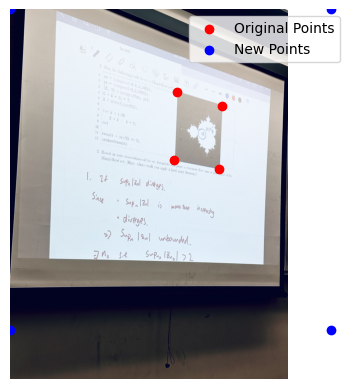

In [510]:
import json

img = plt.imread('../data/IMG_8782.jpg') 
with open('../data/ppt.json', 'r') as f:
    warped_points = json.load(f)

original_pts = np.array(warped_points["im1Points"])
#new_pts = np.array(warped_points["im2Points"])
new_pts = np.array([[0, 0], [3500, 0], [0, 3500], [3500, 3500]])

H = computeH_simple(original_pts,new_pts)
#imwarped_nn = warpImageNearestNeighbor(img,H)
#imwarped_bil = warpImageBilinear(img,H)

# Plot the image
fig, ax = plt.subplots()

# Plot the image
ax.imshow(img)

# Plot the points on the image
ax.scatter(original_pts[:, 0], original_pts[:, 1], c='r', label='Original Points')
ax.scatter(new_pts[:, 0], new_pts[:, 1], c='b', label='New Points')

ax.legend()
ax.axis('off')
plt.show()

Original corners:
[[   0.    0.]
 [3023.    0.]
 [3023. 4031.]
 [   0. 4031.]]
Transformed corners:
[[-9554.00279354 -1200.09943159]
 [ 9165.80162088 -7034.24291878]
 [11170.46049392 16199.47751606]
 [-8949.98899646 13738.18946061]]
Bounding box: x[-9555, 11171], y[-7035, 16200]
min_pair would be: (-9555, -7035)
Cropped output size: 3700 x 3700
Crop bounds: x[-100, 3600], y[-100, 3600]


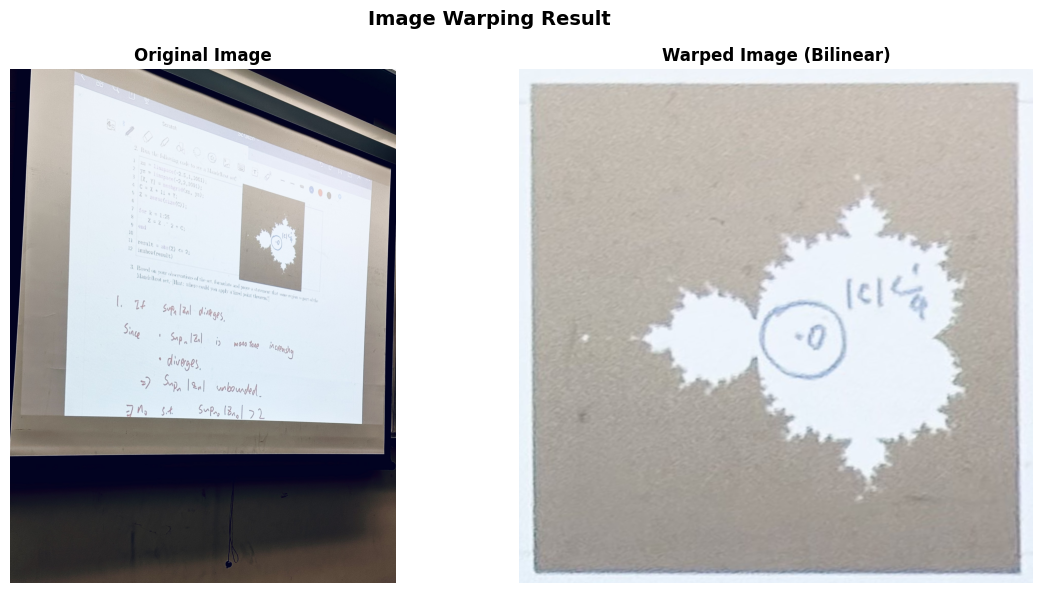

In [513]:
H = computeH_simple(original_pts,new_pts)

#imwarped_nn = warpImageNearestNeighbor(img,H)
#imwarped_bil = warpImageBilinear(img, H)
imwarped_cropped = warpImageBilinear_cropped(img, H, new_pts, padding=100)



display(img, imwarped_cropped, "Bilinear")

In [512]:
print(f"Homography matrix:\n{H}")
output_w, output_h, min_pair = get_output_size(img, H)
print(f"Output size: {output_w} x {output_h}")
print(f"This is {output_w * output_h:,} pixels!")

imwarped_nn = warpImageNearestNeighbor(img,H)
#imwarped_bil = warpImageBilinear(img, H)


display(img, imwarped_nn, "Nearest Neighbor")

#display(img, imwarped_bil, "Bilinear")


Homography matrix:
[[ 5.12094813e+00  2.26226624e-01 -9.55400279e+03]
 [-1.10759324e+00  3.58860211e+00 -1.20009943e+03]
 [-1.16903158e-04 -8.53458611e-06  1.00000000e+00]]
Output size: 20727 x 23236
This is 481,612,572 pixels!


TypeError: warpImage() missing 1 required positional argument: 'new_points'

A.4: Blend the Images into a Mosaic

In [389]:
from scipy import ndimage

def create_distance_weights(mask):
    if not np.any(mask):
        return np.zeros_like(mask, dtype=np.float32)
    
    dist_transform = ndimage.distance_transform_edt(mask)
    
    if np.max(dist_transform) > 0:
        weights = dist_transform / np.max(dist_transform)
    else:
        weights = mask.astype(np.float32)
    
    return weights

In [390]:
def compose_mosaic_proper_blending(img1, img2, H2, interp_func):
 
    h2, w2 = img2.shape[:2]
    corners2 = np.array([[0, 0, 1], [w2-1, 0, 1], [w2-1, h2-1, 1], [0, h2-1, 1]], dtype=np.float32)
    transformed_corners2 = corners2 @ H2.T
    transformed_corners2 = transformed_corners2[:, :2] / transformed_corners2[:, 2:3]

    h1, w1 = img1.shape[:2]
    corners1 = np.array([[0, 0], [w1-1, 0], [w1-1, h1-1], [0, h1-1]], dtype=np.float32)

    all_corners = np.vstack([corners1, transformed_corners2])
    min_x, min_y = np.floor(np.min(all_corners, axis=0)).astype(int)
    max_x, max_y = np.ceil(np.max(all_corners, axis=0)).astype(int)
    mosaic_width = max_x - min_x + 1
    mosaic_height = max_y - min_y + 1

    print(f"Mosaic size: {mosaic_width} x {mosaic_height}")

    T = np.array([[1, 0, -min_x],
                  [0, 1, -min_y],
                  [0, 0, 1]])

    H2_adjusted = T @ H2

    warped_img2 = warpImage(img2, H2_adjusted, interp_func)
    print(f"Warped image size: {warped_img2.shape}")

    offset_x, offset_y = -min_x, -min_y
    
    canvas = np.zeros((mosaic_height, mosaic_width, 4), dtype=np.uint8)
    weight_map = np.zeros((mosaic_height, mosaic_width), dtype=np.float32)
    color_sum = np.zeros((mosaic_height, mosaic_width, 3), dtype=np.float32)
    
    # Place img1
    y1_start, y1_end = offset_y, offset_y + h1
    x1_start, x1_end = offset_x, offset_x + w1
    
    # Simple weights for img1 (all 1.0 for now)
    img1_weights = np.ones((h1, w1), dtype=np.float32)
    
    for c in range(3):
        color_sum[y1_start:y1_end, x1_start:x1_end, c] += (
            img1[:, :, c].astype(np.float32) * img1_weights
        )
    weight_map[y1_start:y1_end, x1_start:x1_end] += img1_weights
    canvas[y1_start:y1_end, x1_start:x1_end, 3] = 255
    
    h_warped, w_warped = warped_img2.shape[:2]
    warped_region = warped_img2[:h_warped, :w_warped]
    warped_mask = warped_region[:, :, 3] > 0
    
    if np.any(warped_mask):
        warped_weights = warped_mask.astype(np.float32)
        
        for c in range(3):
            color_sum[:h_warped, :w_warped, c] += (
                warped_region[:, :, c].astype(np.float32) * warped_weights
            )
        weight_map[:h_warped, :w_warped] += warped_weights
        canvas[:h_warped, :w_warped, 3] = np.maximum(
            canvas[:h_warped, :w_warped, 3], 
            warped_region[:, :, 3]
        )
    
    valid_weights = weight_map > 0
    for c in range(3):
        canvas[:, :, c][valid_weights] = np.clip(
            color_sum[:, :, c][valid_weights] / weight_map[valid_weights], 
            0, 255
        ).astype(np.uint8)

    # Auto-crop 
    alpha_channel = canvas[:, :, 3]
    rows = np.any(alpha_channel > 0, axis=1)
    cols = np.any(alpha_channel > 0, axis=0)
    
    if np.any(rows) and np.any(cols):
        ymin, ymax = np.where(rows)[0][[0, -1]]
        xmin, xmax = np.where(cols)[0][[0, -1]]
        
        pad = 10
        ymin = max(0, ymin - pad)
        ymax = min(mosaic_height-1, ymax + pad)
        xmin = max(0, xmin - pad)
        xmax = min(mosaic_width-1, xmax + pad)
        
        cropped_canvas = canvas[ymin:ymax+1, xmin:xmax+1]
        print(f"Cropped from {mosaic_width}x{mosaic_height} to {cropped_canvas.shape[1]}x{cropped_canvas.shape[0]}")
    else:
        cropped_canvas = canvas
        print("No cropping applied")

    return cropped_canvas

In [ ]:
def warpImage(im, H, interp_func):  ##warpImage with no offset, easier for world coord 
    output_w, output_h, min_pair = get_output_size(im, H)

    if len(im.shape) == 3:
        output = np.zeros((output_h, output_w, 4), dtype=im.dtype)  # RGBA
    else:
        output = np.zeros((output_h, output_w, 2), dtype=im.dtype)

    #assign point coord values 
    y_out, x_out = np.mgrid[0:output_h, 0:output_w]
    

    coords_out = np.stack([x_out, y_out, np.ones_like(x_out)], axis=-1)

    H_inv = np.linalg.inv(H)
    coords_src = (coords_out @ H_inv.T)
    coords_src = coords_src[:, :, :2]/coords_src[:,:,2:3]

    x_src = coords_src[:, :, 0]
    y_src = coords_src[:, :, 1]

    h_src, w_src = im.shape[:2]
    mask = (x_src >= 0) & (x_src <= w_src-1) & (y_src >= 0) & (y_src <= h_src-1)

    if len(im.shape) == 3: 
        for c in range(3): 
            output[:,:,c] = interp_func(im[:,:,c], x_src, y_src)
            output[:,:,c] = output[:,:,c] * mask
        output[:, :, 3] = (mask * 255).astype(im.dtype)  #transparent = 0 
    else: 
        output[:, :, 0] = interp_func(im[:,:,0], x_src, y_src)
        output[:, :, 1] = (mask * 255).astype(im.dtype) 
        
    return output 

def warpImageNearestNeighbor(im, H): 
    return warpImage(im, H, nearest_neighbor_interp)
def warpImageBilinear(im, H):
    return warpImage(im, H, bilinear_interp)

In [515]:
def get_H(json_path): 
    with open(json_path, 'r') as f:
        warped_points = json.load(f)

    original_pts = np.array(warped_points["im1Points"])
    new_pts = np.array(warped_points["im2Points"])


    H = computeH_simple(original_pts,new_pts)
    return H, original_pts, new_pts

In [516]:
H, original_pts, new_pts = get_H('../data/cdt2.json')

img1 = plt.imread('../data/IMG_8863r.jpg') 
img2 = plt.imread('../data/IMG_8862r.jpg') 

mosaic = compose_mosaic_proper_blending(img1, img2, H, nearest_neighbor_interp)


Mosaic size: 4014 x 3032
Warped image size: (3032, 3460, 4)
Cropped from 4014x3032 to 4014x3032


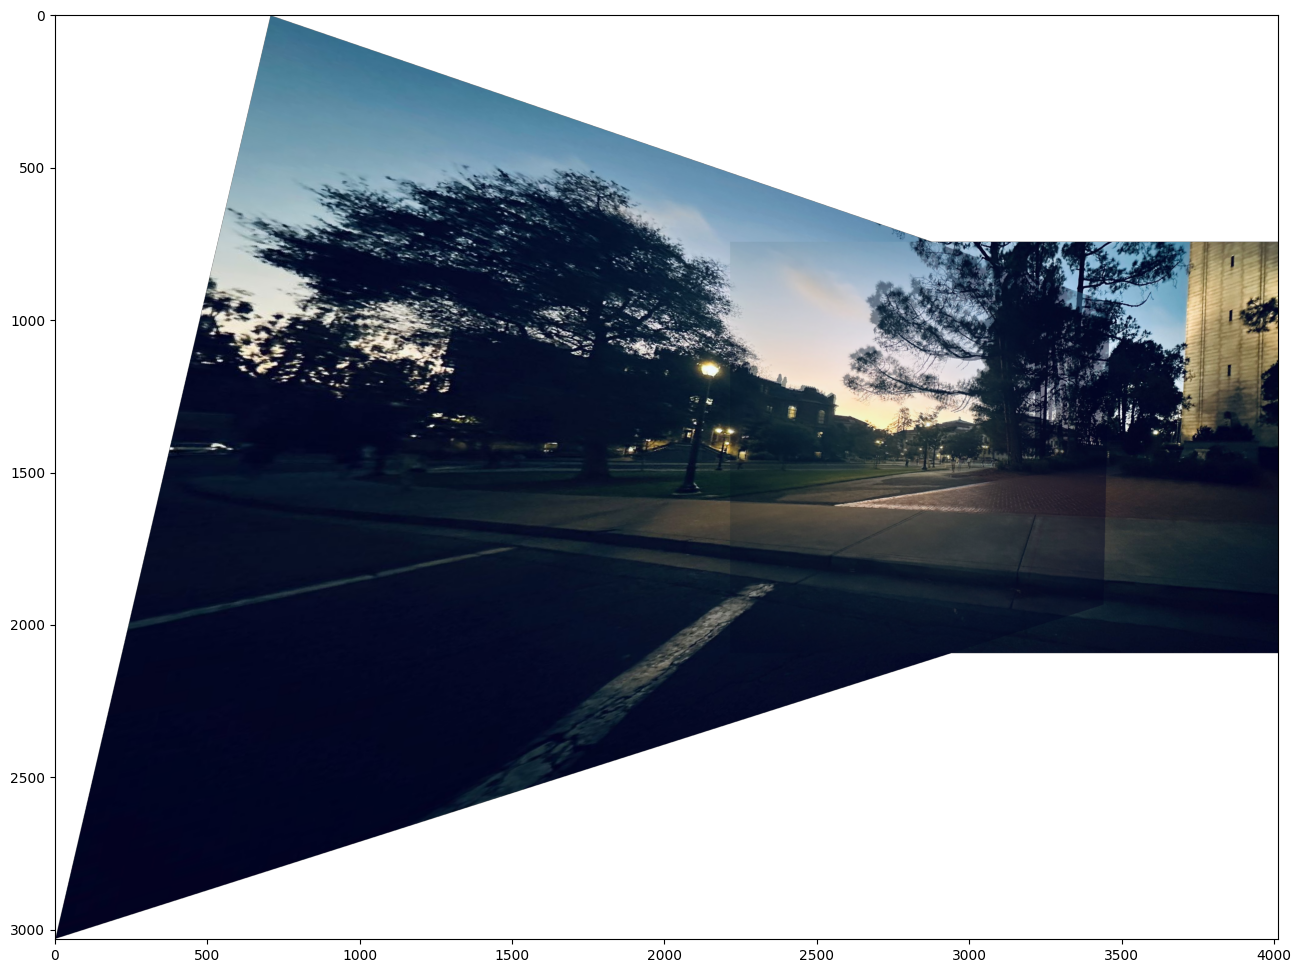

In [517]:

fig, axes = plt.subplots(figsize=(18, 12))
plt.imshow(mosaic)
plt.show()

In [ ]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

def create_blending_mask(warped_img, reference_img):
    
    mask_warped = np.any(warped_img > 0, axis=2).astype(np.uint8)
    mask_reference = np.any(reference_img > 0, axis=2).astype(np.uint8)
    
    dist_warped = ndimage.distance_transform_edt(mask_warped)
    dist_reference = ndimage.distance_transform_edt(mask_reference)
    
    alpha_mask = np.zeros_like(dist_warped, dtype=np.float32)
    
    overlap_mask = (mask_warped > 0) & (mask_reference > 0)
    if np.any(overlap_mask):
        total_dist = dist_warped[overlap_mask] + dist_reference[overlap_mask]
        alpha_mask[overlap_mask] = dist_warped[overlap_mask] / total_dist
    
    warped_only = (mask_warped > 0) & (mask_reference == 0)
    alpha_mask[warped_only] = 1.0
    
    
    return alpha_mask

def blend_images_weighted(img1, img2, alpha_mask):
   
    if len(alpha_mask.shape) == 2:
        alpha_mask = alpha_mask[:, :, np.newaxis]
    
    img1_float = img1.astype(np.float32)
    img2_float = img2.astype(np.float32)
    
    blended = img1_float * alpha_mask + img2_float * (1.0 - alpha_mask)
    
    return np.clip(blended, 0, 255).astype(np.uint8)

def compose_mosaic_distance_blend(img1, img2, H, interp_func):
    
    
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    corners1 = np.array([[0, 0, 1], [w1-1, 0, 1], [w1-1, h1-1, 1], [0, h1-1, 1]], dtype=np.float32)
    corners2 = np.array([[0, 0, 1], [w2-1, 0, 1], [w2-1, h2-1, 1], [0, h2-1, 1]], dtype=np.float32)
    
    transformed_corners2 = (H @ corners2.T).T
    transformed_corners2 = transformed_corners2[:, :2] / transformed_corners2[:, 2:3]
    
    all_corners = np.vstack([corners1[:, :2], transformed_corners2])
    
    min_x, min_y = np.floor(np.min(all_corners, axis=0)).astype(int)
    max_x, max_y = np.ceil(np.max(all_corners, axis=0)).astype(int)
    
    mosaic_width = max_x - min_x + 1
    mosaic_height = max_y - min_y + 1
    
    print(f"Mosaic size: {mosaic_width} x {mosaic_height}")

    T = np.array([[1, 0, -min_x],
                  [0, 1, -min_y],
                  [0, 0, 1]])
    H_adjusted = T @ H

    warped_img2 = warpImage(img2, H_adjusted, interp_func)
    print(f"Warped image size: {warped_img2.shape}")

    canvas = np.zeros((mosaic_height, mosaic_width, 3), dtype=np.uint8)
    
    offset_x, offset_y = -min_x, -min_y
    y1_start, y1_end = offset_y, offset_y + h1
    x1_start, x1_end = offset_x, offset_x + w1
    canvas[y1_start:y1_end, x1_start:x1_end] = img1

    h_warped, w_warped = warped_img2.shape[:2]
    warped_rgb = warped_img2[:, :, :3]  
    
    canvas_region = canvas[:h_warped, :w_warped]
    
    alpha_mask = create_blending_mask(warped_rgb, canvas_region)
    
    blended_region = blend_images_weighted(warped_rgb, canvas_region, alpha_mask)
    
    canvas[:h_warped, :w_warped] = blended_region

    non_empty_mask = np.any(canvas > 0, axis=2)
    rows = np.any(non_empty_mask, axis=1)
    cols = np.any(non_empty_mask, axis=0)
    
    if np.any(rows) and np.any(cols):
        ymin, ymax = np.where(rows)[0][[0, -1]]
        xmin, xmax = np.where(cols)[0][[0, -1]]
        
        pad = 10
        ymin = max(0, ymin - pad)
        ymax = min(mosaic_height-1, ymax + pad)
        xmin = max(0, xmin - pad)
        xmax = min(mosaic_width-1, xmax + pad)
        
        canvas = canvas[ymin:ymax+1, xmin:xmax+1]
        print(f"Cropped to: {canvas.shape[1]} x {canvas.shape[0]}")

    return canvas


Mosaic size: 10692 x 6895
Original bounds: x[0, 10509], y[0, 6894]
Offsets: x=0, y=0
Warped image size: (6895, 10510, 4)
Cropped to: 10692 x 6895


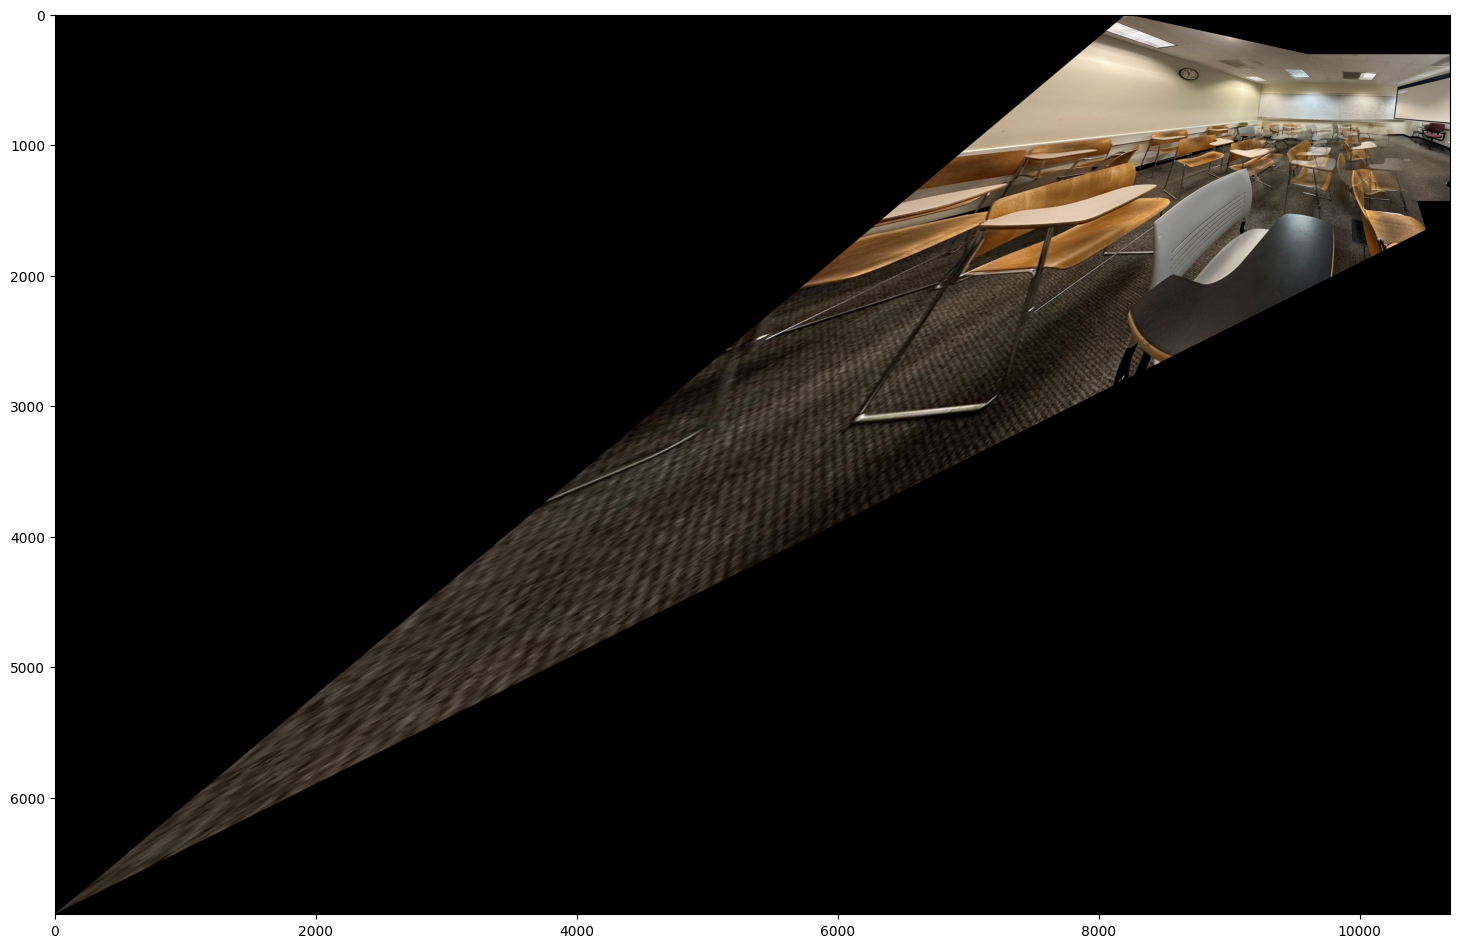

In [ ]:
H, original_pts, new_pts = get_H('../data/trychair.json')

img1 = plt.imread('../data/IMG_8844r.jpg') 
img2 = plt.imread('../data/IMG_8843r.jpg') 

mosaic = compose_mosaic_distance_blend(img1, img2, H, nearest_neighbor_interp)

#mosaic = compose_mosaic_distance_blend(img1, img2, H, bilinear_interp)
fig, axes = plt.subplots(figsize=(18, 12))
plt.imshow(mosaic)
plt.show()